<a href="https://colab.research.google.com/github/Gabioxdj46/ConnectaTel-analysis/blob/main/Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print("Cantidad de valores nulos")
print(users.isna().sum())
print("\nProporción de valores nulos")
print(users.isna().mean())

Cantidad de valores nulos
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print("Cantidad de valores nulos")
print(usage.isna().sum())

print("\nProporción de valores nulos")
print(usage.isna().mean())

Cantidad de valores nulos
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).

* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

  **Respuesta**
- En el dataset de `users`,la columna de `city` tiene 11.7% de nulos, por lo que recomendaria imputar como `"unknown"` o investigar la fuente, antes de analizar por ciudad.
- En el datset `users`, la columna `churn_date` tiene 88.35% de nulos, pero probablemente hay clientes activos y clientes que han cancelado, por lo que se recomienda crear una bandera de churn en lugar de eliminarla.
- En el dataset `usage`, `date` tiene solo 0.125% de nulos, por lo que se recomienda eliminar esas filas si el análisis depende de fechas.
- En el dataset `usage`,las columnas de `duration` y `length` tienen muchos nulos, pero recomiendo analizar por separado, ya que las llamadas usan `duration` y los mensajes usan `length`.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
print(users.describe())

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- En la columna `user_id` ...qué ves.
- En la columna `user_id`, los valores van desde 10000 a 13999, donde no se observan valores inválidos; aunque es numérica, se trata de un identificador, lo cual no debe analizarse estadísticamente como variable de comportamiento.
- En la columna en `age`, se observa un valor mínimo de `-999`, lo cual es imposible para una edad, entonces estaria  representando un sentinel inválido; se recomienda reemplazarlo por nulo y luego imputar o tratarlo según la estrategia de limpieza.

In [ ]:
# explorar columnas numéricas de usage
print(usage.describe())

                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- En la columna `id`, los valores van de 1 a 40000 y parecen funcionar como identificadores únicos de cada registro de uso, por lo que no se estaria interpretando estadísticamente como comportamiento del cliente.

- En la columna `user_id`, los valores van de 10000 a 13999 y parecen corresponder a usuarios válidos; aunque es numérica, esto se usaria para relacionar el uso con cada cliente y no para calcular métricas como promedio o mediana.

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(col)
    print(users[col].value_counts(dropna=False))
    print()


city
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

plan
Basico     2595
Premium    1405
Name: plan, dtype: int64



- La columna `city`, contiene ciudades válidas como `Bogotá`, `CDMX`, `Medellín`, `GDL`, `Cali` y `MTY`, pero también presenta valores faltantes (`NaN`) y el sentinel `"?"`, por lo que se recomienda reemplazar `"?"` por nulo o `"unknown"` antes de u análisis por ciudad.
- La columna `plan`, contiene únicamente las categorías `Basico` y `Premium`, sin valores nulos ni sentinels aparentes, por lo que no se requeriria limpieza adicional en esta etapa.

In [ ]:
# explorar columna categórica de usage
print(usage['type'].value_counts(dropna=False))

text    22092
call    17908
Name: type, dtype: int64


- La columna `type`, contiene únicamente las categorías esperadas `text` con 22092 mensajes y `call` con 17908 llamadas, por lo que no se observan valores inválidos o sentinels en esta columna.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- Encontré valores inválidos o sentinels en la columna `age`, porque aparece el valor `-999`, que no es una edad posible.
- También encontré un sentinel en la columna `city`, porque aparece el valor `"?"`, que no representa una ciudad válida.
- En `plan` y `type` no encontré valores inválidos, ya que solo aparecen categorías esperadas como `Basico`, `Premium`, `text` y `call`.

- ¿Qué acción tomarías?
- En la columma `age`, reemplazaría `-999` por un valor nulo (`NaN`), para que no se distorsione los valores estadísticos como la media, la mediana o los análisis por edad.
- En la columna `city`, reemplazaría `"?"` por `NaN` o por `"unknown"`, porque me representa una ciudad desconocida y no debe analizarse como una ciudad real.
- En `plan` y `type`, no tomaría mimguna acción de limpieza adicional, porque sus valores son consistentes.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [ ]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts(dropna=False).sort_index())

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date`, ...qué ves?
En `reg_date`, se observan registros entre el 2022 y 2024, que están dentro del rango esperado, pero también me aparecen 40 registros del 2026, un año futuro fuera del periodo del dataset; se recomienda tratar estas fechas como inválidas y convertirlas en nulas o excluirlas del análisis temporal.

In [ ]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts(dropna=False).sort_index())

2024.0    39950
NaN          50
Name: date, dtype: int64


En `date`, ...qué ves?  
En `date`, casi todos los registros pertenecen al año 2024, lo cual coincide con el periodo esperado del dataset; sin embargo, aparecen 50 fechas inválidas o faltantes convertidas en `NaN`, por lo que se recomienda excluirlas del análisis temporal o revisarlas bien antes de usar la columna.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- En `reg_date`, aparecen 40 registros con año 2026, lo cual está fuera del rango esperado, porque el dataset solo contiene información hasta 2024; se recomienda convertir estas fechas en nulas o excluirlas del análisis temporal.
- En `date`, se observan 39950 registros válidos del año 2024 y 50 fechas inválidas o faltantes convertidas en `NaN`; se recomienda eliminar estos registros únicamente para análisis basados en fechas.
- Sí aparecen años imposibles en `reg_date`, porque 2026 es un año futuro respecto al periodo del dataset. No se observan años futuros en `date`, pero sí fechas inválidas convertidas en `NaN`.
  
- ¿Qué harías con ellas?
- 1. Convertirlas en nulas para no usarlas como fechas válidas.
- 2. Excluirlas del análisis temporal.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users[users['age'] != -999]['age'].median()

users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [ ]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
print(usage.groupby("type")["duration"].apply(lambda x: x.isna().mean()))

type
call    0.000000
text    0.999276
Name: duration, dtype: float64


In [ ]:
# Verificación MAR en usage (Missing At Random) para length
print(usage.groupby("type")["length"].apply(lambda x: x.isna().mean()))

type
call    0.99933
text    0.00000
Name: length, dtype: float64


Diagnostico de nulos en `duration` y `length`
En `duration`, los valores nulos dependen de la columna `type`, aparecen principalmente cuando el registro corresponde a `text`, lo cual es esperado porque los mensajes no tienen duración de llamada. Por eso, se recomienda dejar esos valores como nulos.
En `length`, los valores nulos también dependen de la columna `type`, aparecen principalmente cuando el registro corresponde a `call`, de la misma manera es lo esperado porque las llamadas no tienen longitud de mensaje. Por eso, se recomienda dejar esos valores como nulos.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

user_profile[columnas_numericas].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  

Para cada histograma,

-
Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas


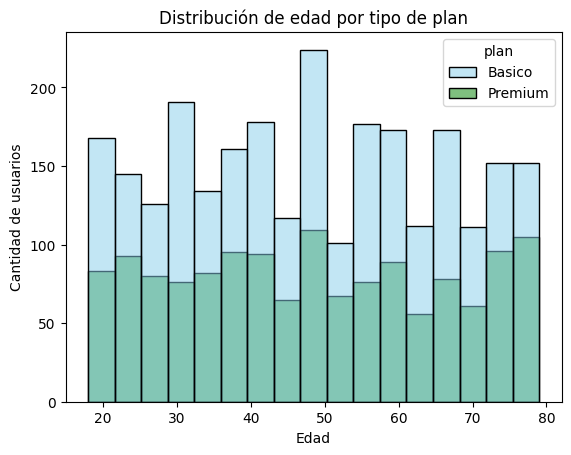

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Distribución de edad por tipo de plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights:
- La Distribución de `age` muestra usuarios entre aproximadamente 18 y 79 años. Tanto en el plan `Basico`, como en el plan `Premium`, por lo que no se observa un patrón fuerte donde un plan pertenezca a un solo grupo de edad específico.
- La distribución parece relativamente equilibrada, sin un sesgo fuerte hacia las edades de jóvenes o mayores.

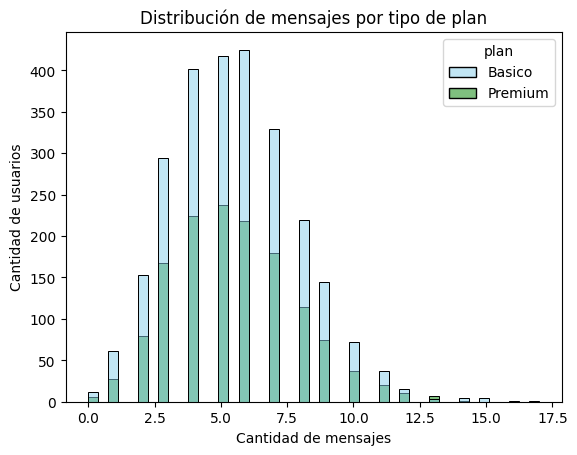

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Distribución de mensajes por tipo de plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights:
- En `cant_mensajes`, la mayoría de usuarios se concentra entre aproximadamente en un envio de 3 y 8 mensajes. Los usuarios del plan `Basico` aparecen con mayor cantidad en casi todos los rangos, porque hay más usuarios en el plan Básico.
- No se observa una diferencia extrema entre los planes; ambos muestran un comportamiento similar. La distribución está ligeramente sesgada a la derecha, porque existen pocos usuarios con cantidades altas de envio de mensajes.

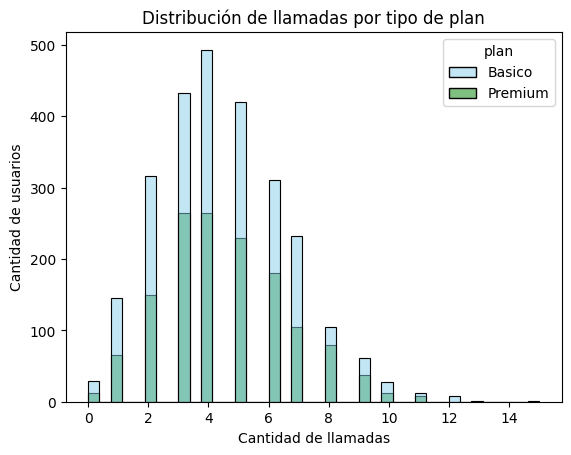

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Distribución de llamadas por tipo de plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights:
- En `cant_llamadas`, la mayoría de usuarios se concentra aproximadamente entre 2 y 7 llamadas, con un comportamiento típico cercano a las 4 llamadas. El plan `Basico` muestra más usuarios en la mayoría de rangos, porque en parte es el plan con mayor cantidad de clientes.
- La distribución está ligeramente sesgada a la derecha, ya que la mayoría de usuarios tienen pocas o moderadas llamadas realizadas, pero existen algunos usuarios con valores altos en la cantidad de llamadas realizadas.

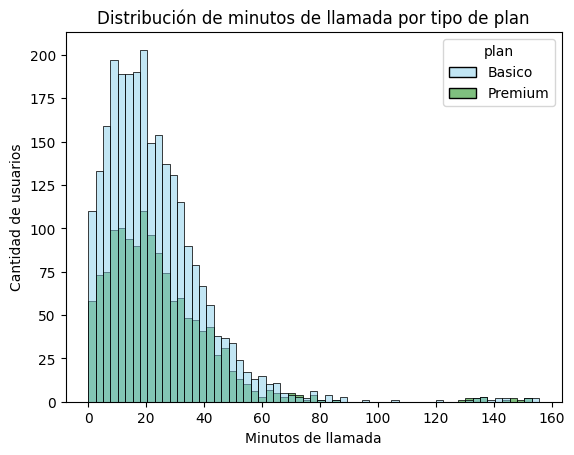

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Distribución de minutos de llamada por tipo de plan')
plt.xlabel('Minutos de llamada')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights:
- En `cant_minutos_llamada`, la mayoría de usuarios se concentra aproximadamente entre 0 y 40 minutos de llamada. Sin embargo, existen algunos usuarios con valores mucho más altos, llegando a valores superiores a los 100 minutos.
- La distribución está sesgada a la derecha, porque la mayor parte de los usuarios tienen un tiempo de duracion de la llamada bajo o moderado , mientras que una cantidad baja de usuarios presentan con valores muy altos en la duracion de sus llamadas. Estos casos podrían representar usuarios intensivos o posibles outliers que deben revisarse en la siguiente etapa.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**
Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

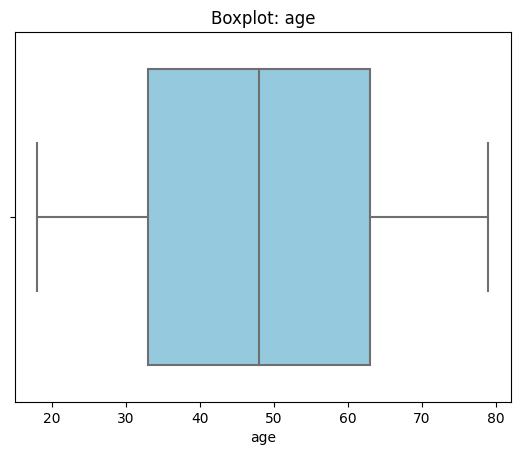

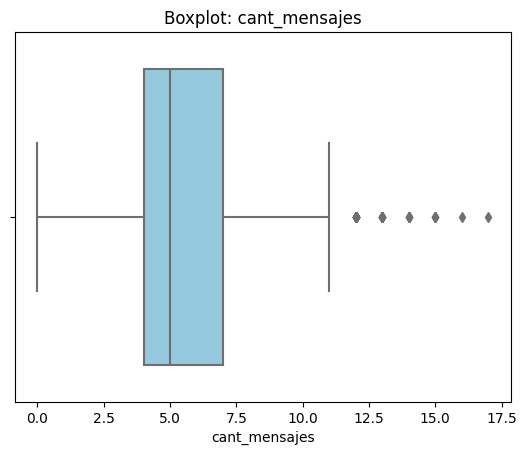

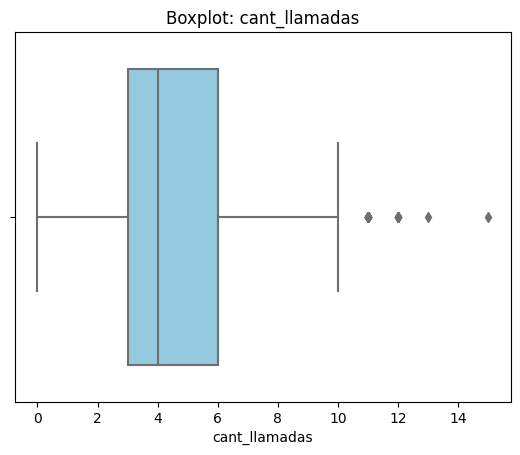

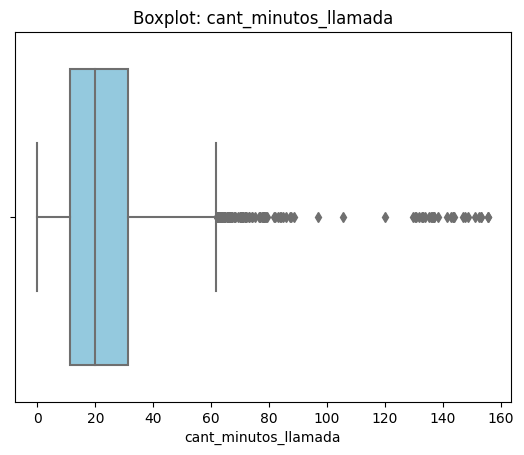

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(x=user_profile[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights: (Presenta o no Outliers?)
- Age: ...
- No presenta outliers visibles. Las edades se encuentran dentro de un rango razonable, aproximadamente entre 18 y 79 años. La caja está entre edades adultas, medias y mayores, y no se observan puntos fuera de los bigotes.
- cant_mensajes: ...
- Sí presenta outliers superiores. La mayoría de usuarios envía mensajes en una cantidad moderada de aproximadamente entre 4 y 7 mensajes, pero aparecen algunos usuarios con valores más altos, entre 12 a 17 mensajes.
- cant_llamadas: ...
- Sí presenta outliers superiores. La mayoría de usuarios realiza entre 3 y 6 llamadas, pero algunos usuarios tienden a hacer más llamadas de lo normal, el cual es entre 11 y 15 llamadas aproximadamente.
- cant_minutos_llamada: ...
- Sí presenta outliers superiores claros. La mayoría de usuarios acumula pocos o moderados minutos en la duracion de su llamada, pero existen usuarios con valores mucho más altos, incluso superiores a los 100 minutos. Estos casos podrían representar usuarios intensivos o comportamientos atípicos que deben revisarse.

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    print(col)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Límite superior:", limite_superior)
    print("Máximo:", user_profile[col].max())
    print("Cantidad de outliers superiores:", len(user_profile[user_profile[col] > limite_superior]))
    print()



cant_mensajes
Q1: 4.0
Q3: 7.0
IQR: 3.0
Límite superior: 11.5
Máximo: 17.0
Cantidad de outliers superiores: 46

cant_llamadas
Q1: 3.0
Q3: 6.0
IQR: 3.0
Límite superior: 10.5
Máximo: 15.0
Cantidad de outliers superiores: 30

cant_minutos_llamada
Q1: 11.12
Q3: 31.415
IQR: 20.295
Límite superior: 61.8575
Máximo: 155.69
Cantidad de outliers superiores: 109



In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: mantener o no outliers, porqué?
- Mantendría los outliers, porque valores entre 12 a 17 mensajes no son imposibles; representan usuarios con mayor actividad de mensajería. Se recomienda analizarlos como clientes intensivos, no eliminarlos automáticamente.
- cant_llamadas: mantener o no outliers, porqué?
- Mantendría los outliers, porque un usuario si puede realizar entre 11 y 15 llamadas y esto podria ser un comportamiento válido de usuarios con alto uso en llamadas. Estos casos deben revisarse como posible segmento de clientes intensivos, no eliminarse directamente.
- cant_minutos_llamada: mantener o no outliers, porqué?
- Los Mantendría los outliers, pero los marcaría para una revisión, porque hay valores mucho más altos que el comportamiento típico. En la vida real esto si es posible en un servicio de telecomunicaciones. Pueden representar clientes intensivos o segmentos de alto valor.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
import numpy as np
user_profile[['cant_mensajes', 'cant_llamadas']] = user_profile[['cant_mensajes', 'cant_llamadas']].fillna(0)

user_profile['grupo_uso'] = np.where(
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    'Bajo uso',
    np.where(
        (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10),
        'Uso medio',
        'Alto uso'
    )
)


In [ ]:
# verificar cambios
user_profile[['user_id', 'cant_mensajes', 'cant_llamadas', 'grupo_uso']].head()

,user_id,cant_mensajes,cant_llamadas,grupo_uso
0,10000,7.0,3.0,Uso medio
1,10001,5.0,10.0,Alto uso
2,10002,5.0,2.0,Uso medio
3,10003,11.0,3.0,Alto uso
4,10004,4.0,3.0,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(
    user_profile['age'] < 30,
    'Joven',
    np.where(
        user_profile['age'] < 60,
        'Adulto',
        'Adulto Mayor'
    )
)

In [ ]:
# verificar cambios
user_profile[['user_id', 'age', 'grupo_edad']].head()

,user_id,age,grupo_edad
0,10000,38.0,Adulto
1,10001,53.0,Adulto
2,10002,57.0,Adulto
3,10003,69.0,Adulto Mayor
4,10004,63.0,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

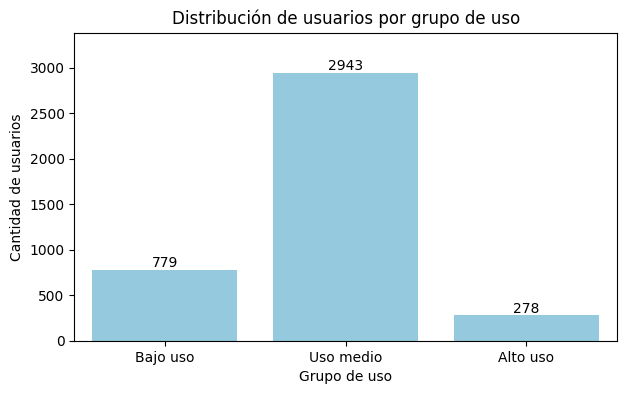

In [ ]:
# Visualización de los segmentos por uso
plt.figure(figsize=(7, 4))

ax = sns.countplot(
    data=user_profile,
    x='grupo_uso',
    order=['Bajo uso', 'Uso medio', 'Alto uso'],
    color='skyblue'
)

plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')

# Calcular la altura máxima para dar espacio arriba
max_height = max([barra.get_height() for barra in ax.patches])
plt.ylim(0, max_height * 1.15)

# Agregar valores encima de las barras
for barra in ax.patches:
    altura = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        altura,
        int(altura),
        ha='center',
        va='bottom'
    )

plt.show()

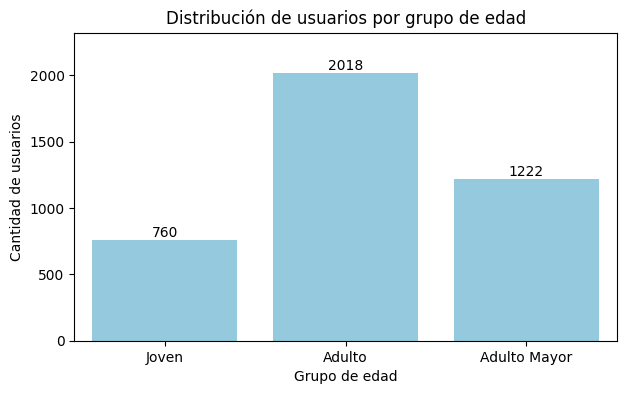

In [ ]:
# Visualización de los segmentos por edad

plt.figure(figsize=(7, 4))

ax = sns.countplot(
    data=user_profile,
    x='grupo_edad',
    order=['Joven', 'Adulto', 'Adulto Mayor'],
    color='skyblue'
)

plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')

# Calcular la altura máxima para dar espacio arriba
max_height = max([barra.get_height() for barra in ax.patches])
plt.ylim(0, max_height * 1.15)

# Agregar valores encima de las barras
for barra in ax.patches:
    altura = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        altura,
        int(altura),
        ha='center',
        va='bottom'
    )

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
En el dataset `users`, se detectaron valores faltantes en la columna `city`. Inicialmente había 469 valores nulos, equivalentes al 11.725% de los usuarios. Además, se encontró un valor sentinel `"?"` en 96 registros, por lo que fue reemplazado por `pd.NA`. Después de la limpieza, la columna `city` quedó con 565 valores faltantes en total. Se recomienda conservarlos como nulos, ya que representan una proporción considerable y eliminar esas filas podría reducir información útil de los usuarios.

También se detectó un valor inválido en `age`: el sentinel `-999`, el cual no representa una edad posible. Este valor fue reemplazado por la mediana de edad, ya que la edad es una variable importante para la segmentación de clientes.

En la columna `reg_date`, se encontraron 40 registros con año 2026, aunque el análisis solo considera datos registrados hasta 2024. Estas fechas fueron marcadas como nulas porque representan fechas futuras fuera del rango válido.

En el dataset `usage`, se detectaron 50 valores nulos en `date`, equivalentes al 0.125% de los registros. Al ser una proporción muy baja, se recomienda excluirlos del análisis temporal o mantenerlos como nulos según el análisis específico.

Las columnas `duration` y `length` tienen muchos valores nulos, pero se confirmó que dependen de la columna `type`. En los mensajes (`text`), `duration` aparece nulo porque los mensajes no tienen duración; en las llamadas (`call`), `length` aparece nulo porque las llamadas no tienen longitud de texto. Por esta razón, estos nulos se consideran MAR y se mantienen como nulos, ya que no representan errores de captura.

🔍 **Segmentos por Edad**

Se identificaron tres grupos de edad: `Joven`, `Adulto` y `Adulto Mayor`.

El grupo más grande es `Adulto`, con 2018 usuarios, lo que representa aproximadamente la mitad de la base de clientes. Esto indica que ConnectaTel tiene una base fuerte de usuarios adultos.

El grupo `Adulto Mayor` tiene 1222 usuarios, por lo que también representa un segmento importante para el negocio. Este grupo puede requerir planes simples, atención clara y beneficios enfocados en llamadas.

El grupo `Joven` tiene 760 usuarios, siendo el segmento más pequeño. Esto puede representar una oportunidad de crecimiento si se diseñan campañas o planes más atractivos para usuarios jóvenes.

📊 **Segmentos por Nivel de Uso**

Se identificaron tres grupos de uso: `Bajo uso`, `Uso medio` y `Alto uso`.

El segmento más grande es `Uso medio`, con 2943 usuarios. Esto indica que la mayoría de clientes tiene un comportamiento moderado de llamadas y mensajes.

El segmento `Bajo uso` tiene 779 usuarios. Estos clientes podrían tener menor interacción con los servicios móviles, por lo que pueden requerir estrategias de activación, promociones o planes más simples.

El segmento `Alto uso` tiene 278 usuarios. Aunque es el grupo más pequeño, puede ser uno de los más valiosos para ConnectaTel, porque representa clientes intensivos, con mayor necesidad de servicios y posible interés en planes premium, beneficios adicionales o paquetes de mayor capacidad.

🚨 **Outliers y patrones de uso extremo**

Se detectaron outliers superiores en las variables de uso.

En `cant_mensajes`, el límite superior por IQR fue 11.5 mensajes y el máximo observado fue 17 mensajes. Se identificaron 46 usuarios con valores superiores al rango típico. Estos casos no parecen errores, sino usuarios con mayor actividad de mensajería.

En `cant_llamadas`, el límite superior por IQR fue 10.5 llamadas y el máximo observado fue 15 llamadas. Se identificaron 30 usuarios con valores superiores al rango típico. Estos usuarios podrían representar clientes con mayor necesidad de comunicación por llamada.

En `cant_minutos_llamada`, el límite superior por IQR fue 61.86 minutos y el máximo observado fue 155.69 minutos. Se identificaron 109 usuarios con consumo alto de minutos. Estos casos deben mantenerse y analizarse, ya que pueden representar usuarios intensivos o clientes de alto valor.

No se recomienda eliminar automáticamente estos outliers, porque los valores son posibles dentro del negocio de telecomunicaciones. En lugar de eliminarlos, se recomienda marcarlos para análisis comercial y posible segmentación.

💡 **Recomendaciones**

ConnectaTel debería mantener los outliers de uso y analizarlos como posibles clientes intensivos, especialmente aquellos con muchos minutos de llamada. Estos usuarios podrían recibir ofertas de planes con más minutos, beneficios premium o programas de fidelización.

Para el segmento `Uso medio`, que concentra la mayor parte de los usuarios, se recomienda optimizar los planes actuales, ya que representa el comportamiento típico de la base de clientes.

Para el segmento `Bajo uso`, se podrían diseñar campañas de activación o planes más económicos, buscando aumentar el uso del servicio y reducir el riesgo de abandono.

Para el segmento `Adulto Mayor`, se recomienda evaluar planes con beneficios claros en llamadas y soporte simple. Para el segmento `Joven`, se podrían crear campañas comerciales más atractivas enfocadas en la flexibilidad, datos móviles o beneficios digitales.

En conclusión, la base de clientes de ConnectaTel está compuesta principalmente por usuarios adultos y de uso medio, pero los usuarios de alto uso y los outliers representan una oportunidad comercial importante para mejorar la oferta de planes, aumentar la retención y diseñar productos más alineados con las necesidades reales de los clientes.

Link a repositorio público del proyecto: `LINK a tu repo aquí`